<a href="https://colab.research.google.com/github/parulgoell/ai-attendance-agent/blob/main/Energy_Distribution_Agents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

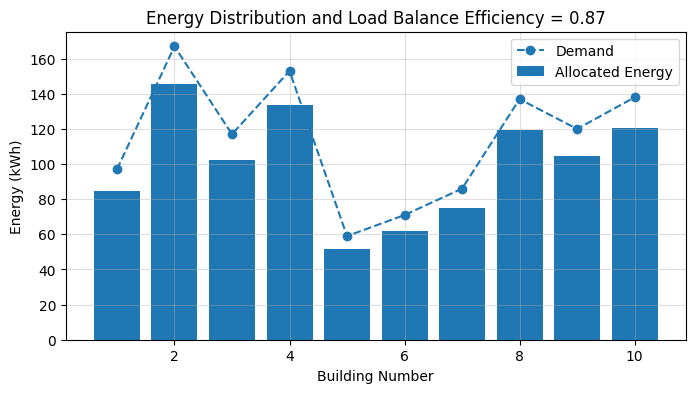

In [1]:
# -------------------------------------------------------
# Energy Distribution Agents : Rule-Based Load Balancing
# -------------------------------------------------------

import numpy as np                  # For mathematical operations
import matplotlib.pyplot as plt     # For plotting load balance efficiency

# -----------------------------
# 1. Setup Simulation Parameters
# -----------------------------

np.random.seed(0)                    # Fix random generation for reproducibility

num_buildings = 10                   # Total number of buildings in the grid
total_energy_supply = 1000           # Total energy available (kWh)

# Random energy demand per building (between 50 and 200 kWh)
demand = np.random.randint(50, 200, num_buildings)

# Create an array to store actual assigned energy after balancing
supply = np.zeros(num_buildings)

# -----------------------------
# 2. Rule-Based Energy Balancing
# -----------------------------

remaining_energy = total_energy_supply     # Track unused energy during distribution

# Rule: Buildings with higher demand get proportionally more energy
priority = demand / demand.sum()           # Normalize demands to get priority weights

# Initial allocation based on priority weights
initial_alloc = priority * total_energy_supply

# Apply a stricter rule: do not exceed actual building demand
for i in range(num_buildings):             # Iterate through buildings
    alloc = min(initial_alloc[i], demand[i])   # Supply can't exceed demand
    supply[i] = alloc                        # Store allocated energy
    remaining_energy -= alloc                # Deduct from grid energy

# -----------------------------
# 3. Redistribute Leftover Energy
# -----------------------------

# If energy remains, redistribute equally among buildings still needing energy
if remaining_energy > 0:
    buildings_still_needing = demand - supply          # How much each building still wants
    need_positive = buildings_still_needing > 0        # Boolean mask of buildings with unmet demand

    # Distribute remaining energy proportionally to unmet demand
    if need_positive.any():                            # Check if any building still needs energy
        weights = buildings_still_needing[need_positive]
        weights = weights / weights.sum()              # Normalize unmet demand for weighting

        # Assign leftover energy proportionally
        supply[need_positive] += weights * remaining_energy

# -----------------------------
# 4. Compute Load Balance Efficiency
# -----------------------------

# Efficiency formula: (total supplied energy) / (total demand capped by supply limit)
efficiency = supply.sum() / demand.sum()

# -----------------------------
# 5. Output Graph: Efficiency Trend
# -----------------------------

plt.figure(figsize=(8, 4))               # Set figure size
plt.bar(range(1, num_buildings + 1), supply, label="Allocated Energy")  # Bar for supplied energy
plt.plot(range(1, num_buildings + 1), demand, 'o--', label="Demand")    # Dots for demand
plt.xlabel("Building Number")            # X-axis label
plt.ylabel("Energy (kWh)")               # Y-axis label
plt.title(f"Energy Distribution and Load Balance Efficiency = {efficiency:.2f}")  # Chart title
plt.legend()                             # Show legend
plt.grid(alpha=0.4)                      # Add soft grid
plt.show()                               # Display the final plot
